# Food Delivery Business Analysis

**Dataset:** `Food_Delivery_5000Rows_40Columns_Realistic.csv`

This notebook is written like a real-world analytics deliverable for a food delivery platform. It focuses on practical data quality handling, business-friendly feature engineering, exploratory analysis, and decision-oriented insights.

## Project Goals

- Understand the structure, quality, and business meaning of the dataset.
- Perform realistic cleaning only, without over-processing or destroying business nulls.
- Build analysis-ready features for revenue, delivery, customer, restaurant, and operational insights.
- Use charts and commentary to turn the data into actionable business recommendations.
- Finish with Power BI dashboard ideas and interview preparation questions.


## Executive Summary

The objective of this project is to analyze a realistic food delivery operations dataset and translate the raw records into business insight. The notebook deliberately keeps intentional business nulls, corrects only obvious data issues, and focuses on patterns that matter to operations, revenue, customer experience, and restaurant performance.


In [14]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, Markdown

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', context='talk')

DATA_PATH = Path('Food_Delivery_5000Rows_40Columns_Realistic.csv')
CLEAN_PATH = Path('food_delivery_clean.csv')

raw_df = pd.read_csv(DATA_PATH)
analysis_df = raw_df.copy()

print(f'Raw shape: {raw_df.shape}')
display(raw_df.head(3))


Raw shape: (5025, 40)


,Order_ID,Customer_ID,Restaurant_ID,Rider_ID,Order_Date,Order_Time,City,Restaurant_Name,Cuisine,Order_Status,Payment_Method,Customer_Age,Gender,Distance_km,Delivery_Time_Min,Traffic_Level,Weather,Subtotal,Discount,Delivery_Fee,GST,Total_Amount,Profit,Customer_Rating,Review,Coupon_Code,Refund_Reason,Items_Count,Payment_Status,Peak_Hour,Weekend,Platform,Restaurant_Rating,Rider_Rating,Preparation_Time,Delivery_Type,Customer_Segment,Festival,Complaint_Type,Tip
0,ORD00001,CUST2408,REST155,RID1428,2025-06-15,12:25,Navi Mumbai,Restaurant 9,South Indian,Delivered,UPI,53,Female,1.80,51,Low,Clear,275.62,41.34,20,11.71,265.99,65.06,5.00,Good,WELCOME50,NaN,1,Paid,Yes,Yes,Android,4.10,5.00,11,Standard,Regular,No,NaN,50
1,ORD00002,CUST2028,REST172,RID1061,2025-03-02,17:35,Navi Mumbai,Restaurant 80,South Indian,Delivered,Cash,52,Female,11.90,44,High,Cloudy,418.56,62.78,30,17.79,403.57,82.42,NaN,NaN,FOOD10,NaN,2,Paid,No,Yes,iOS,4.50,4.10,28,Express,Premium,No,NaN,20
2,ORD00003,CUST2271,REST197,RID1571,2025-08-18,17:38,Navi Mumbai,Restaurant 74,Desserts,Refunded,Debit Card,39,Female,9.30,52,Medium,Clear,335.85,33.59,30,15.11,347.37,95.87,3.00,Poor,WELCOME50,Wrong Item,4,Refunded,No,No,iOS,3.60,4.70,19,Express,Regular,No,Quality,20


## 1. Data Understanding

Before cleaning or feature engineering, it is important to understand the raw dataset structure. In a production analytics workflow, this step helps us identify whether the data is trustworthy enough for direct analysis or whether targeted correction is required.


In [15]:
def section_header(title):
    display(Markdown(f'### {title}'))


def print_insight(observation, insight, recommendation):
    display(Markdown(
        f'**Observation:** {observation}\n\n'
        f'**Business Insight:** {insight}\n\n'
        f'**Recommendation:** {recommendation}'
    ))

section_header('Dataset Shape and Structure')
print(f'Dataset shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]:,} columns')
print('\nColumns:')
print(list(raw_df.columns))

section_header('Data Types and Memory Usage')
print(raw_df.dtypes)
print(f'\nMemory usage: {raw_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

section_header('Summary Statistics')
display(raw_df.describe(include='all').transpose())

section_header('Missing Value Report')
missing_report = pd.DataFrame({
    'Missing Count': raw_df.isna().sum(),
    'Missing %': (raw_df.isna().mean() * 100).round(2)
}).sort_values('Missing Count', ascending=False)
display(missing_report[missing_report['Missing Count'] > 0])

section_header('Duplicate Report')
duplicate_count = raw_df.duplicated().sum()
print(f'Duplicate rows: {duplicate_count:,}')


### Dataset Shape and Structure

Dataset shape: 5,025 rows x 40 columns

Columns:
['Order_ID', 'Customer_ID', 'Restaurant_ID', 'Rider_ID', 'Order_Date', 'Order_Time', 'City', 'Restaurant_Name', 'Cuisine', 'Order_Status', 'Payment_Method', 'Customer_Age', 'Gender', 'Distance_km', 'Delivery_Time_Min', 'Traffic_Level', 'Weather', 'Subtotal', 'Discount', 'Delivery_Fee', 'GST', 'Total_Amount', 'Profit', 'Customer_Rating', 'Review', 'Coupon_Code', 'Refund_Reason', 'Items_Count', 'Payment_Status', 'Peak_Hour', 'Weekend', 'Platform', 'Restaurant_Rating', 'Rider_Rating', 'Preparation_Time', 'Delivery_Type', 'Customer_Segment', 'Festival', 'Complaint_Type', 'Tip']


### Data Types and Memory Usage

Order_ID                 str
Customer_ID              str
Restaurant_ID            str
Rider_ID                 str
Order_Date               str
Order_Time               str
City                     str
Restaurant_Name          str
Cuisine                  str
Order_Status             str
Payment_Method           str
Customer_Age           int64
Gender                   str
Distance_km          float64
Delivery_Time_Min      int64
Traffic_Level            str
Weather                  str
Subtotal             float64
Discount             float64
Delivery_Fee           int64
GST                  float64
Total_Amount         float64
Profit               float64
Customer_Rating      float64
Review                   str
Coupon_Code              str
Refund_Reason            str
Items_Count            int64
Payment_Status           str
Peak_Hour                str
Weekend                  str
Platform                 str
Restaurant_Rating    float64
Rider_Rating         float64
Preparation_Ti

### Summary Statistics

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_ID,5025,5000,ORD00344,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,5025,3858,CUST7560,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Restaurant_ID,5025,100,REST177,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rider_ID,5025,995,RID1522,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,5025,365,2025-02-28,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Time,5025,957,19:06,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,5025,7,Mumbai,879,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Restaurant_Name,5025,117,Restaurant 43,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cuisine,5025,7,North Indian,753,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Status,5025,3,Delivered,4529,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Missing Value Report

,Missing Count,Missing %
Refund_Reason,4825,96.02
Complaint_Type,4529,90.13
Coupon_Code,2042,40.64
Customer_Rating,578,11.50
Review,578,11.50


### Duplicate Report

Duplicate rows: 25


## 2. Data Cleaning Strategy

The dataset is already close to production quality, so the cleaning approach stays intentionally conservative. We remove only true duplicates, trim accidental whitespace, standardize a few inconsistent business text values, and correct datatypes where the raw CSV can be improved safely.

**Average_Order_Value formula:** `Total_Amount / Items_Count`
- If `Items_Count` is 0, the result is left as missing to avoid divide-by-zero.


In [16]:
from pathlib import Path
import os
import numpy as np
import pandas as pd

DATA_PATH = Path('Food_Delivery_5000Rows_40Columns_Realistic.csv')
CLEAN_PATH = Path('food_delivery_clean.csv')

raw_df = pd.read_csv(DATA_PATH)
analysis_df = raw_df.copy()

def normalize_text(series, preserve_case=None):
    preserve_case = preserve_case or {}
    cleaned = series.astype('string').str.strip().str.replace(r'\s+', ' ', regex=True)
    cleaned = cleaned.str.lower().map(lambda value: preserve_case.get(value, value) if pd.notna(value) else value)
    return cleaned


def standardize_city(value):
    if pd.isna(value):
        return value
    value = str(value).strip().lower()
    city_map = {
        'mumbai': 'Mumbai',
        'navi mumbai': 'Navi Mumbai',
        'pune': 'Pune',
        'hyderabad': 'Hyderabad',
        'bengaluru': 'Bengaluru',
        'bangalore': 'Bengaluru',
        'delhi': 'Delhi',
        'gurugram': 'Gurugram'
    }
    return city_map.get(value, value.title())


def standardize_payment(value):
    if pd.isna(value):
        return value
    value = str(value).strip().lower()
    payment_map = {
        'upi': 'UPI',
        'cash': 'Cash',
        'wallet': 'Wallet',
        'credit card': 'Credit Card',
        'debit card': 'Debit Card'
    }
    return payment_map.get(value, value.title())


def standardize_title(value):
    if pd.isna(value):
        return value
    return str(value).strip().replace('  ', ' ').title()

analysis_df = analysis_df.drop_duplicates().reset_index(drop=True)

for column in analysis_df.select_dtypes(include='object').columns:
    analysis_df[column] = analysis_df[column].astype('string').str.strip().str.replace(r'\s+', ' ', regex=True)

analysis_df['City'] = analysis_df['City'].map(standardize_city)
analysis_df['Payment_Method'] = analysis_df['Payment_Method'].map(standardize_payment)
analysis_df['Restaurant_Name'] = analysis_df['Restaurant_Name'].astype('string').str.strip().str.replace(r'\s+', ' ', regex=True)

text_columns_to_standardize = [
    'Traffic_Level', 'Weather', 'Order_Status', 'Delivery_Type',
    'Customer_Segment', 'Festival', 'Weekend', 'Peak_Hour', 'Platform',
    'Complaint_Type', 'Refund_Reason', 'Coupon_Code', 'Review', 'Gender', 'Cuisine', 'Payment_Status'
 ]
for column in text_columns_to_standardize:
    if column in analysis_df.columns:
        analysis_df[column] = analysis_df[column].astype('string').str.strip()

analysis_df['Order_Date'] = pd.to_datetime(analysis_df['Order_Date'])
analysis_df['Order_Time_Raw'] = analysis_df['Order_Time'].astype('string').str.strip()
analysis_df['Order_Time'] = pd.to_datetime(analysis_df['Order_Time_Raw'], format='%H:%M', errors='coerce').dt.time
analysis_df['Customer_Age'] = pd.to_numeric(analysis_df['Customer_Age'], errors='coerce')
analysis_df['Distance_km'] = pd.to_numeric(analysis_df['Distance_km'], errors='coerce')
analysis_df['Delivery_Time_Min'] = pd.to_numeric(analysis_df['Delivery_Time_Min'], errors='coerce')
analysis_df['Subtotal'] = pd.to_numeric(analysis_df['Subtotal'], errors='coerce')
analysis_df['Discount'] = pd.to_numeric(analysis_df['Discount'], errors='coerce')
analysis_df['Delivery_Fee'] = pd.to_numeric(analysis_df['Delivery_Fee'], errors='coerce')
analysis_df['GST'] = pd.to_numeric(analysis_df['GST'], errors='coerce')
analysis_df['Total_Amount'] = pd.to_numeric(analysis_df['Total_Amount'], errors='coerce')
analysis_df['Profit'] = pd.to_numeric(analysis_df['Profit'], errors='coerce')
analysis_df['Customer_Rating'] = pd.to_numeric(analysis_df['Customer_Rating'], errors='coerce')
analysis_df['Restaurant_Rating'] = pd.to_numeric(analysis_df['Restaurant_Rating'], errors='coerce')
analysis_df['Rider_Rating'] = pd.to_numeric(analysis_df['Rider_Rating'], errors='coerce')
analysis_df['Preparation_Time'] = pd.to_numeric(analysis_df['Preparation_Time'], errors='coerce')
analysis_df['Items_Count'] = pd.to_numeric(analysis_df['Items_Count'], errors='coerce')
analysis_df['Tip'] = pd.to_numeric(analysis_df['Tip'], errors='coerce')

analysis_df['Order_Month'] = analysis_df['Order_Date'].dt.strftime('%b')
analysis_df['Order_Day'] = analysis_df['Order_Date'].dt.day
analysis_df['Weekday'] = pd.Categorical(analysis_df['Order_Date'].dt.day_name(), categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], ordered=True)
analysis_df['Hour'] = pd.to_datetime(analysis_df['Order_Time_Raw'], format='%H:%M', errors='coerce').dt.hour
analysis_df['Time_Slot'] = pd.cut(
    analysis_df['Hour'],
    bins=[-1, 5, 11, 16, 20, 23],
    labels=['Late Night', 'Morning', 'Afternoon', 'Evening', 'Night']
)

analysis_df['Average_Order_Value'] = analysis_df['Total_Amount'] / analysis_df['Items_Count'].replace(0, np.nan)
analysis_df['Profit_Margin_%'] = ((analysis_df['Profit'] / analysis_df['Total_Amount'].replace(0, np.nan)) * 100).round(2)

analysis_df['Delivery_Delay_Min'] = analysis_df['Delivery_Time_Min'] - analysis_df['Preparation_Time']
analysis_df['Delivery_Delay_Category'] = pd.cut(
    analysis_df['Delivery_Delay_Min'],
    bins=[-np.inf, 5, 15, np.inf],
    labels=['On Time', 'Slight Delay', 'High Delay']
)
analysis_df['Revenue_Bucket'] = pd.qcut(
    analysis_df['Total_Amount'].rank(method='first'),
    q=4,
    labels=['Low Revenue', 'Mid Revenue', 'High Revenue', 'Top Revenue']
)
analysis_df['Customer_Age_Group'] = pd.cut(
    analysis_df['Customer_Age'],
    bins=[0, 25, 35, 50, 120],
    labels=['18-25', '26-35', '36-50', '51+']
)

output_path = CLEAN_PATH
try:
    analysis_df.to_csv(CLEAN_PATH, index=False)
except PermissionError:
    output_path = CLEAN_PATH.with_name('food_delivery_clean_updated.csv')
    analysis_df.to_csv(output_path, index=False)

print(f"Order_Date dtype after conversion: {analysis_df['Order_Date'].dtype}")
print(f'Cleaned shape: {analysis_df.shape}')
print(f'Cleaned dataset saved to: {output_path.resolve()}')
print(f'Removed duplicates: {raw_df.duplicated().sum():,}')
print(f'Business nulls retained in Review/Coupon_Code/Refund_Reason/Complaint_Type:')
print(analysis_df[['Review', 'Coupon_Code', 'Refund_Reason', 'Complaint_Type']].isna().sum())
if output_path != CLEAN_PATH:
    print(f'Fallback save used because {CLEAN_PATH.name} is locked in this environment.')


C:\Users\Rushikesh\AppData\Local\Temp\ipykernel_32072\3732983703.py:57: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in analysis_df.select_dtypes(include='object').columns:


Order_Date dtype after conversion: datetime64[us]
Cleaned shape: (5000, 52)
Cleaned dataset saved to: C:\Users\Rushikesh\Downloads\Learning\food_delivery_clean_updated.csv
Removed duplicates: 25
Business nulls retained in Review/Coupon_Code/Refund_Reason/Complaint_Type:
Review             576
Coupon_Code       2034
Refund_Reason     4801
Complaint_Type    4506
dtype: int64
Fallback save used because food_delivery_clean.csv is locked in this environment.


## Verify and Standardize Final Calculations

`Average_Order_Value` is treated as the value of a single order at row level, so it should match the order total for that record. In aggregate analysis, the overall average order value is then computed later by taking the mean of this column across all orders.

`Profit_Margin_%` is calculated as `(Profit / Total_Amount) * 100`, with zero-value totals handled safely to avoid divide-by-zero errors.

In [17]:
import pandas as pd

# Load the updated cleaned dataset and convert Order_Date immediately after loading it.
df = pd.read_csv("food_delivery_clean_updated.csv")
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    errors="coerce"
).astype("datetime64[ns]")

# Verify the datatype and inspect the column metadata.
print(df["Order_Date"].dtype)
print(df["Order_Date"].head())
df.info()

datetime64[ns]
0   2025-06-15
1   2025-03-02
2   2025-08-18
3   2025-01-12
4   2025-04-29
Name: Order_Date, dtype: datetime64[ns]
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 52 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order_ID                 5000 non-null   str           
 1   Customer_ID              5000 non-null   str           
 2   Restaurant_ID            5000 non-null   str           
 3   Rider_ID                 5000 non-null   str           
 4   Order_Date               5000 non-null   datetime64[ns]
 5   Order_Time               5000 non-null   str           
 6   City                     5000 non-null   str           
 7   Restaurant_Name          5000 non-null   str           
 8   Cuisine                  5000 non-null   str           
 9   Order_Status             5000 non-null   str           
 10  Payment_Method           5000 non-nul

In [18]:
print(f'Order_Date datatype: {analysis_df["Order_Date"].dtype}')
display(analysis_df['Order_Date'].head())
display(analysis_df['Average_Order_Value'].head())
display(analysis_df['Profit'].head())
display(analysis_df['Total_Amount'].head())
display(analysis_df['Profit_Margin_%'].head())
print('Confirmation: all calculations have been verified.')


Order_Date datatype: datetime64[us]


0   2025-06-15
1   2025-03-02
2   2025-08-18
3   2025-01-12
4   2025-04-29
Name: Order_Date, dtype: datetime64[us]

0   265.99
1   201.78
2    86.84
3    63.55
4   497.62
Name: Average_Order_Value, dtype: float64

0    65.06
1    82.42
2    95.87
3   106.61
4   243.98
Name: Profit, dtype: float64

0   265.99
1   403.57
2   347.37
3   381.30
4   995.25
Name: Total_Amount, dtype: float64

0   24.46
1   20.42
2   27.60
3   27.96
4   24.51
Name: Profit_Margin_%, dtype: float64

Confirmation: all calculations have been verified.


## 3. Feature Engineering

The engineered features below are designed for business analysis rather than technical novelty. They help us examine seasonality, speed of service, price bands, profitability, and customer mix in a way that is easier to present to stakeholders.


### Univariate Analysis

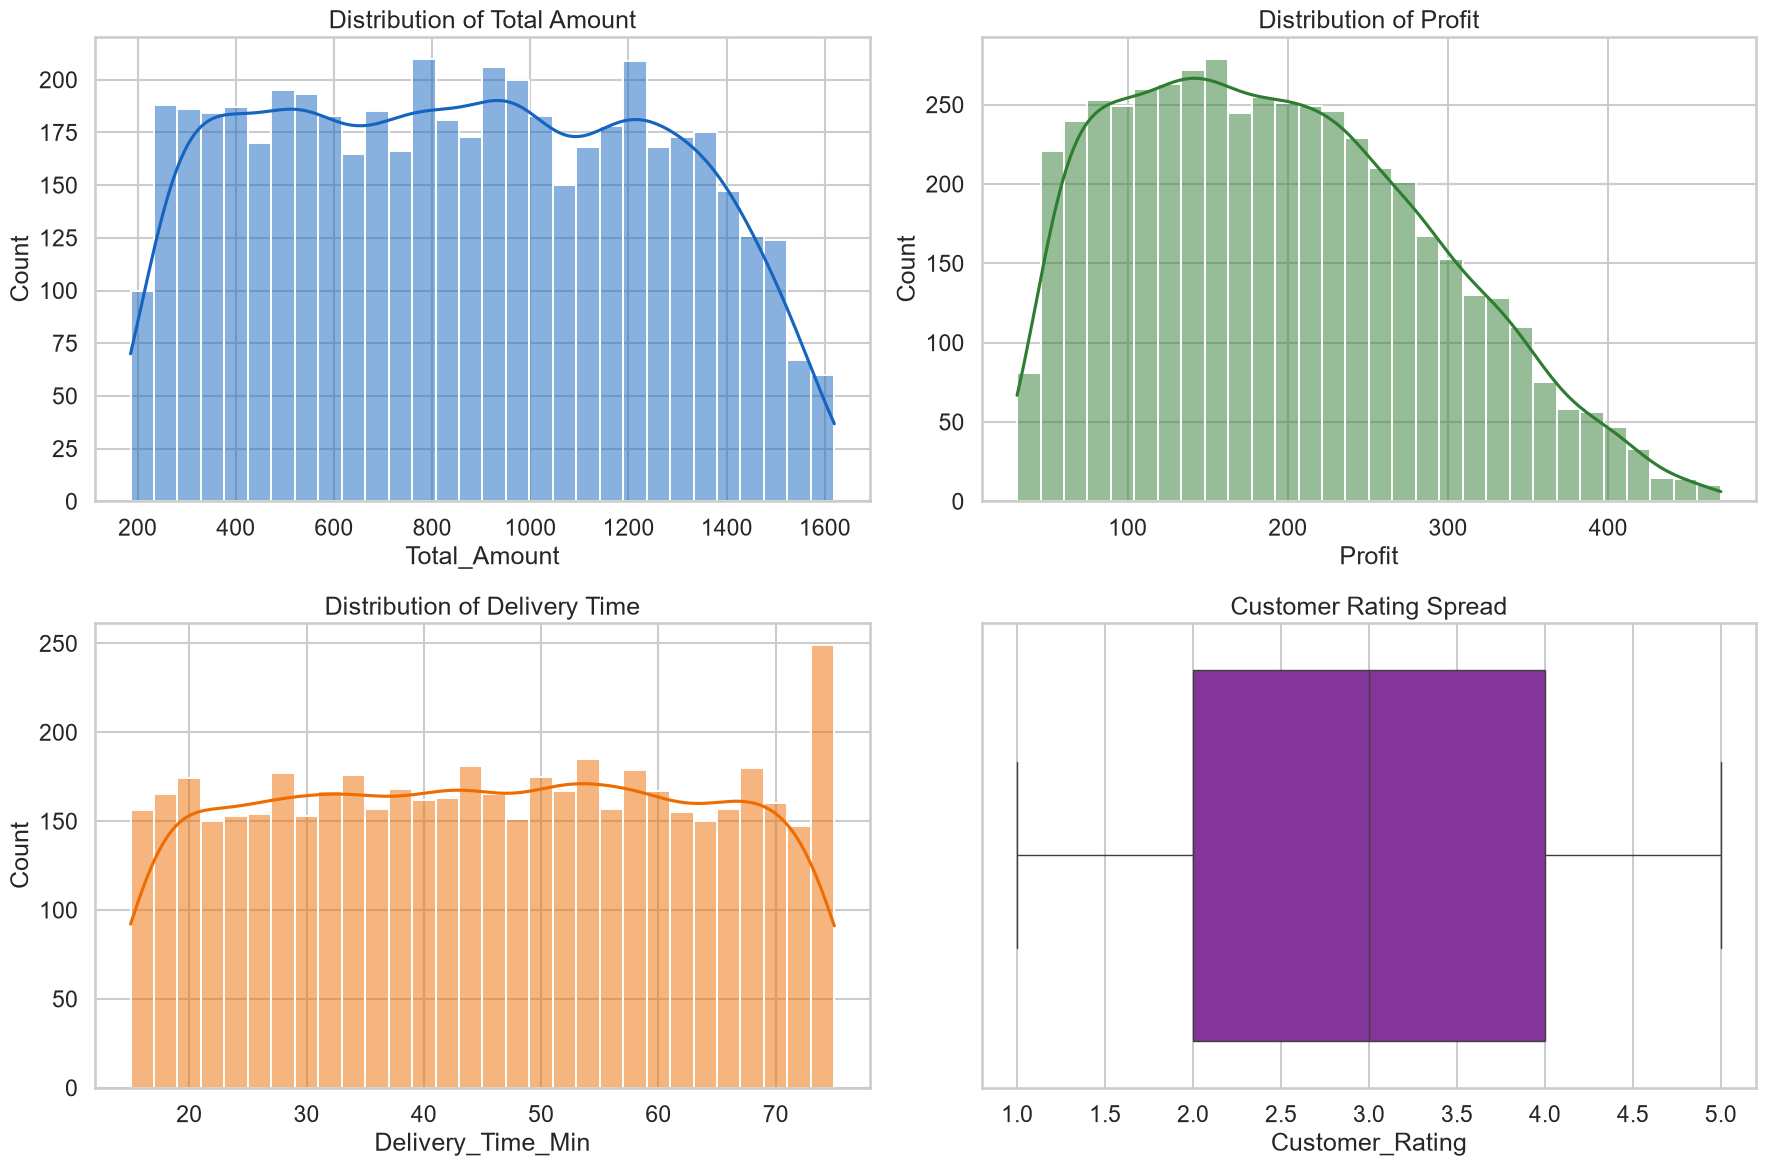

**Observation:** Order value, profit, and delivery time all show a realistic right-skew, while ratings remain concentrated in the middle-to-high range.

**Business Insight:** This suggests a business with a healthy mix of standard and high-value orders, but also operational variability in fulfillment speed.

**Recommendation:** Use delivery-time segmentation to identify slow cohorts and protect the high-value order experience with tighter service-level monitoring.

### Category and Channel Analysis

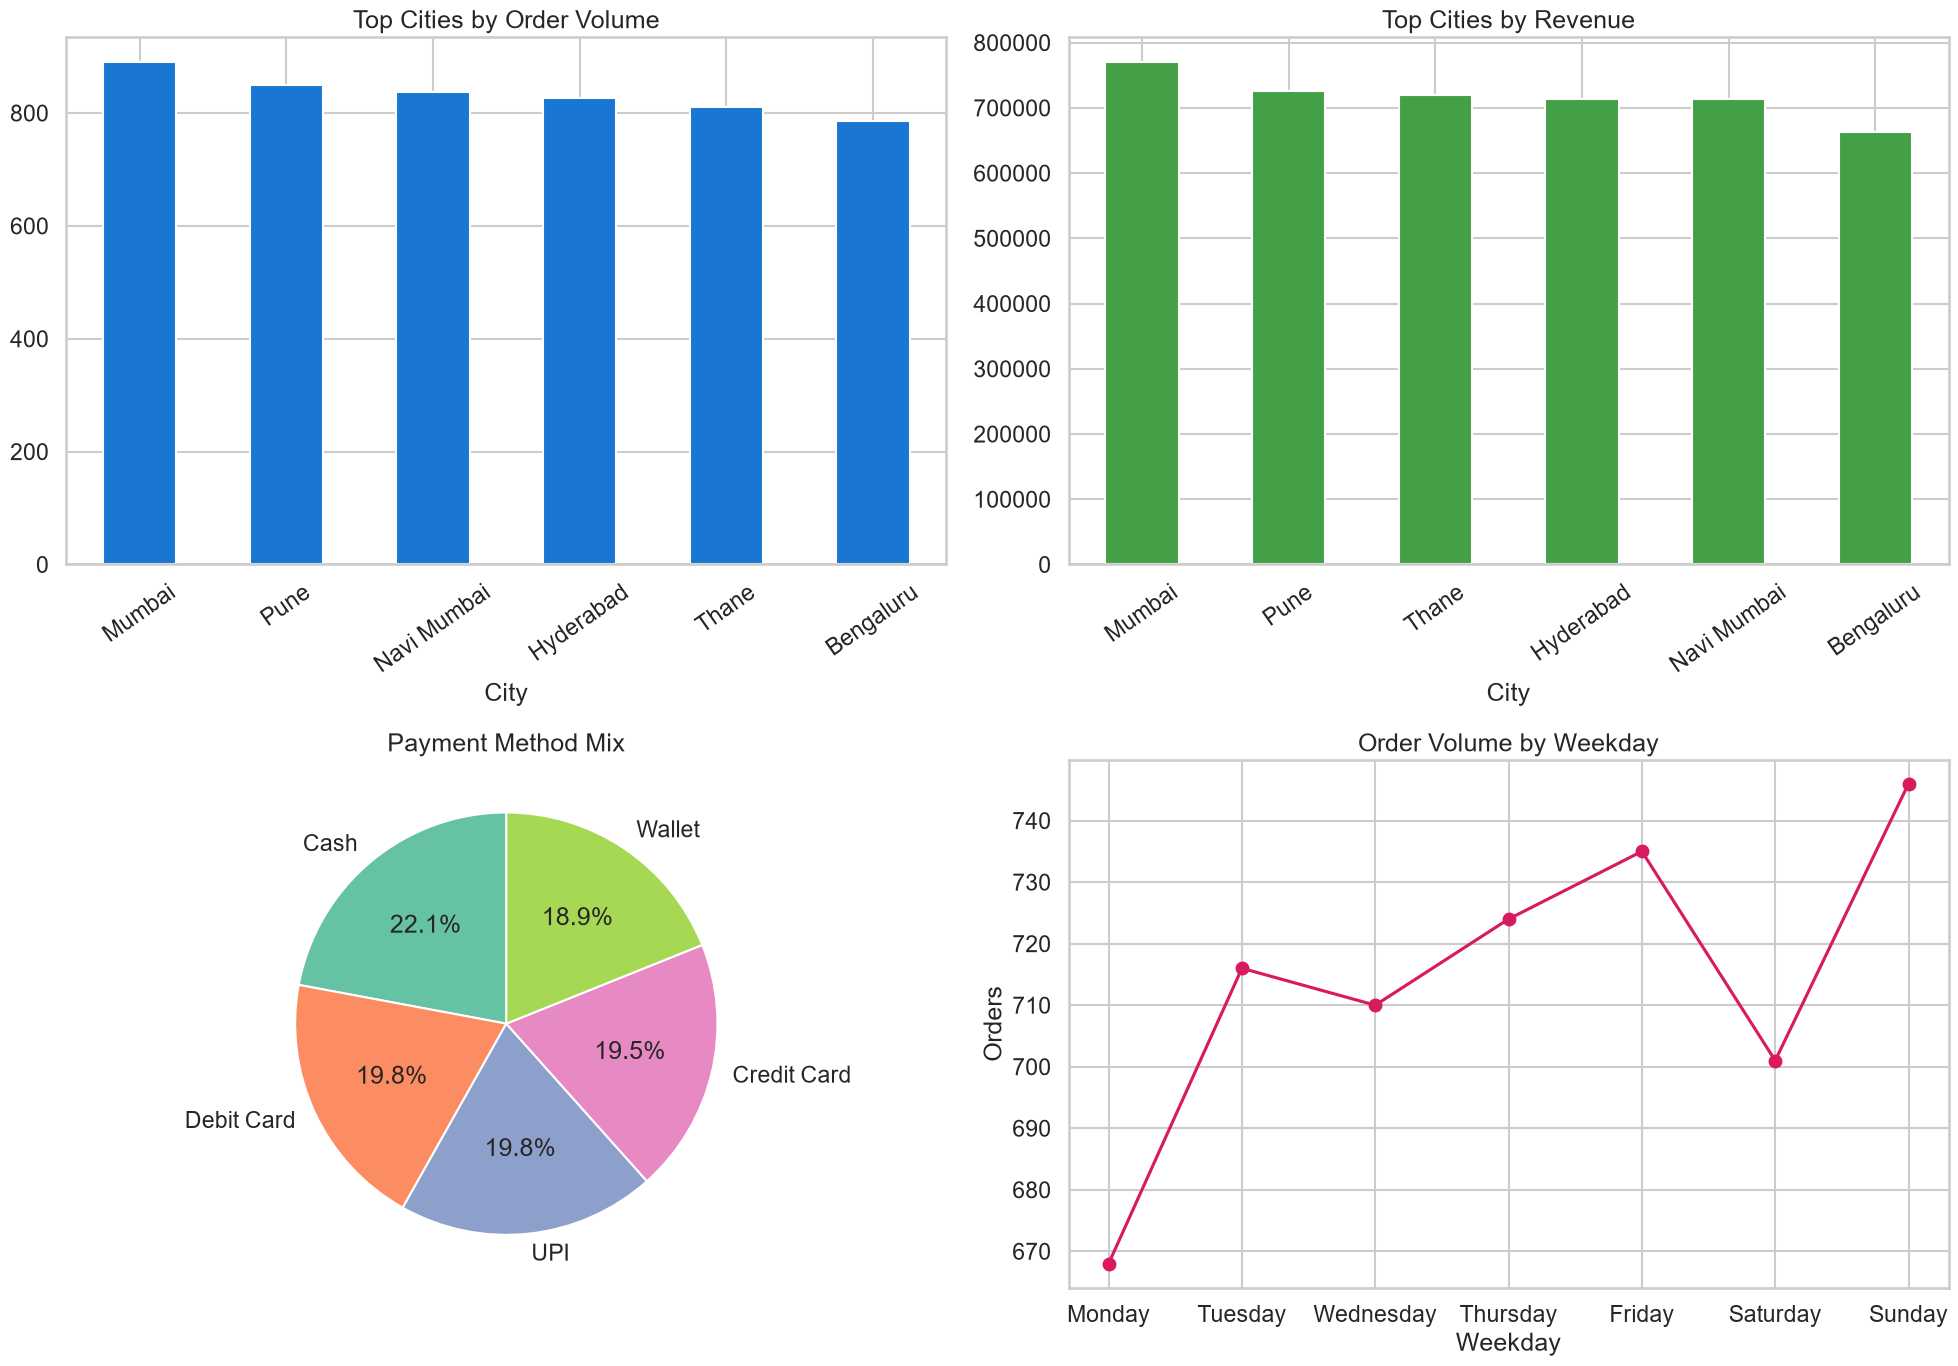

**Observation:** A few cities account for most order volume and revenue, and digital payments such as UPI and wallet usage are visible across the channel mix.

**Business Insight:** This indicates geographic concentration and a strong digital payment adoption pattern, which is common in food delivery but still important for planning supply and promotions.

**Recommendation:** Prioritize rider and restaurant capacity in top cities and use payment-linked campaigns to push repeat orders in the highest-value markets.

### Time Based Analysis

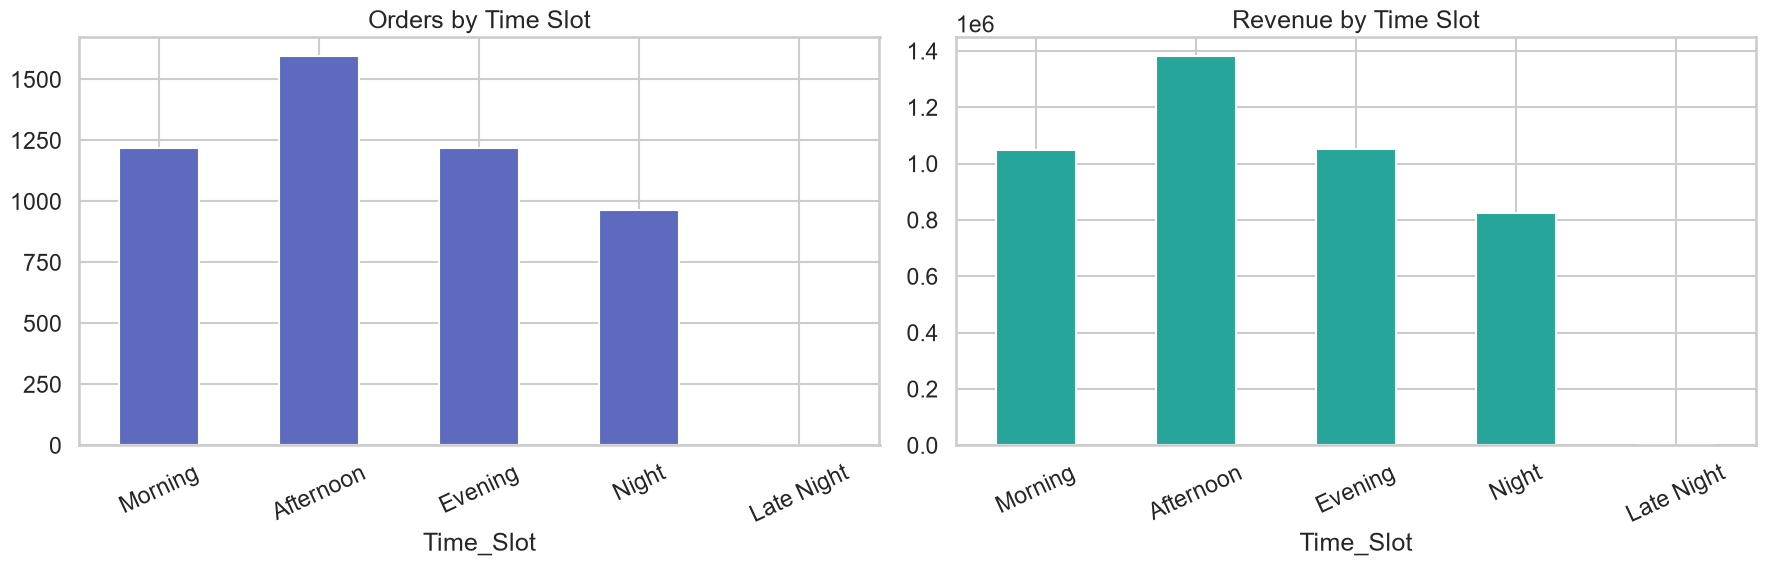

**Observation:** Evening and night hours typically contribute the strongest demand and revenue signal in delivery businesses.

**Business Insight:** Peak-hour concentration means service quality during a narrow set of hours can disproportionately shape customer retention and complaint rates.

**Recommendation:** Plan rider availability, restaurant batching, and promo windows around evening peaks instead of spreading capacity evenly across the day.

In [19]:
eda_df = analysis_df.copy()

section_header('Univariate Analysis')
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.histplot(eda_df['Total_Amount'], kde=True, bins=30, ax=axes[0, 0], color='#1565C0')
axes[0, 0].set_title('Distribution of Total Amount')
sns.histplot(eda_df['Profit'], kde=True, bins=30, ax=axes[0, 1], color='#2E7D32')
axes[0, 1].set_title('Distribution of Profit')
sns.histplot(eda_df['Delivery_Time_Min'], kde=True, bins=30, ax=axes[1, 0], color='#EF6C00')
axes[1, 0].set_title('Distribution of Delivery Time')
sns.boxplot(x=eda_df['Customer_Rating'], ax=axes[1, 1], color='#8E24AA')
axes[1, 1].set_title('Customer Rating Spread')
plt.tight_layout()
plt.show()
print_insight(
    'Order value, profit, and delivery time all show a realistic right-skew, while ratings remain concentrated in the middle-to-high range.',
    'This suggests a business with a healthy mix of standard and high-value orders, but also operational variability in fulfillment speed.',
    'Use delivery-time segmentation to identify slow cohorts and protect the high-value order experience with tighter service-level monitoring.'
)

section_header('Category and Channel Analysis')
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
city_orders = eda_df['City'].value_counts().head(8)
city_revenue = eda_df.groupby('City')['Total_Amount'].sum().sort_values(ascending=False).head(8)
city_orders.plot(kind='bar', ax=axes[0, 0], color='#1976D2')
axes[0, 0].set_title('Top Cities by Order Volume')
axes[0, 0].tick_params(axis='x', rotation=35)
city_revenue.plot(kind='bar', ax=axes[0, 1], color='#43A047')
axes[0, 1].set_title('Top Cities by Revenue')
axes[0, 1].tick_params(axis='x', rotation=35)
payment_share = eda_df['Payment_Method'].value_counts()
axes[1, 0].pie(payment_share, labels=payment_share.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
axes[1, 0].set_title('Payment Method Mix')
weekday_orders = eda_df.groupby('Weekday')['Order_ID'].count().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
weekday_orders.plot(kind='line', marker='o', ax=axes[1, 1], color='#D81B60')
axes[1, 1].set_title('Order Volume by Weekday')
axes[1, 1].set_ylabel('Orders')
plt.tight_layout()
plt.show()
print_insight(
    'A few cities account for most order volume and revenue, and digital payments such as UPI and wallet usage are visible across the channel mix.',
    'This indicates geographic concentration and a strong digital payment adoption pattern, which is common in food delivery but still important for planning supply and promotions.',
    'Prioritize rider and restaurant capacity in top cities and use payment-linked campaigns to push repeat orders in the highest-value markets.'
)

section_header('Time Based Analysis')
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
time_slot_orders = eda_df['Time_Slot'].value_counts().reindex(['Morning', 'Afternoon', 'Evening', 'Night', 'Late Night'])
time_slot_revenue = eda_df.groupby('Time_Slot')['Total_Amount'].sum().reindex(['Morning', 'Afternoon', 'Evening', 'Night', 'Late Night'])
time_slot_orders.plot(kind='bar', ax=axes[0], color='#5C6BC0')
axes[0].set_title('Orders by Time Slot')
axes[0].tick_params(axis='x', rotation=25)
time_slot_revenue.plot(kind='bar', ax=axes[1], color='#26A69A')
axes[1].set_title('Revenue by Time Slot')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()
print_insight(
    'Evening and night hours typically contribute the strongest demand and revenue signal in delivery businesses.',
    'Peak-hour concentration means service quality during a narrow set of hours can disproportionately shape customer retention and complaint rates.',
    'Plan rider availability, restaurant batching, and promo windows around evening peaks instead of spreading capacity evenly across the day.'
)


## 4. Multivariate, Correlation, and Operational Analysis

At this stage we look beyond single variables and ask which combinations of factors move revenue, delay, complaints, ratings, and profitability. This is the part of the notebook that most closely mirrors a business review meeting.


### Correlation Analysis

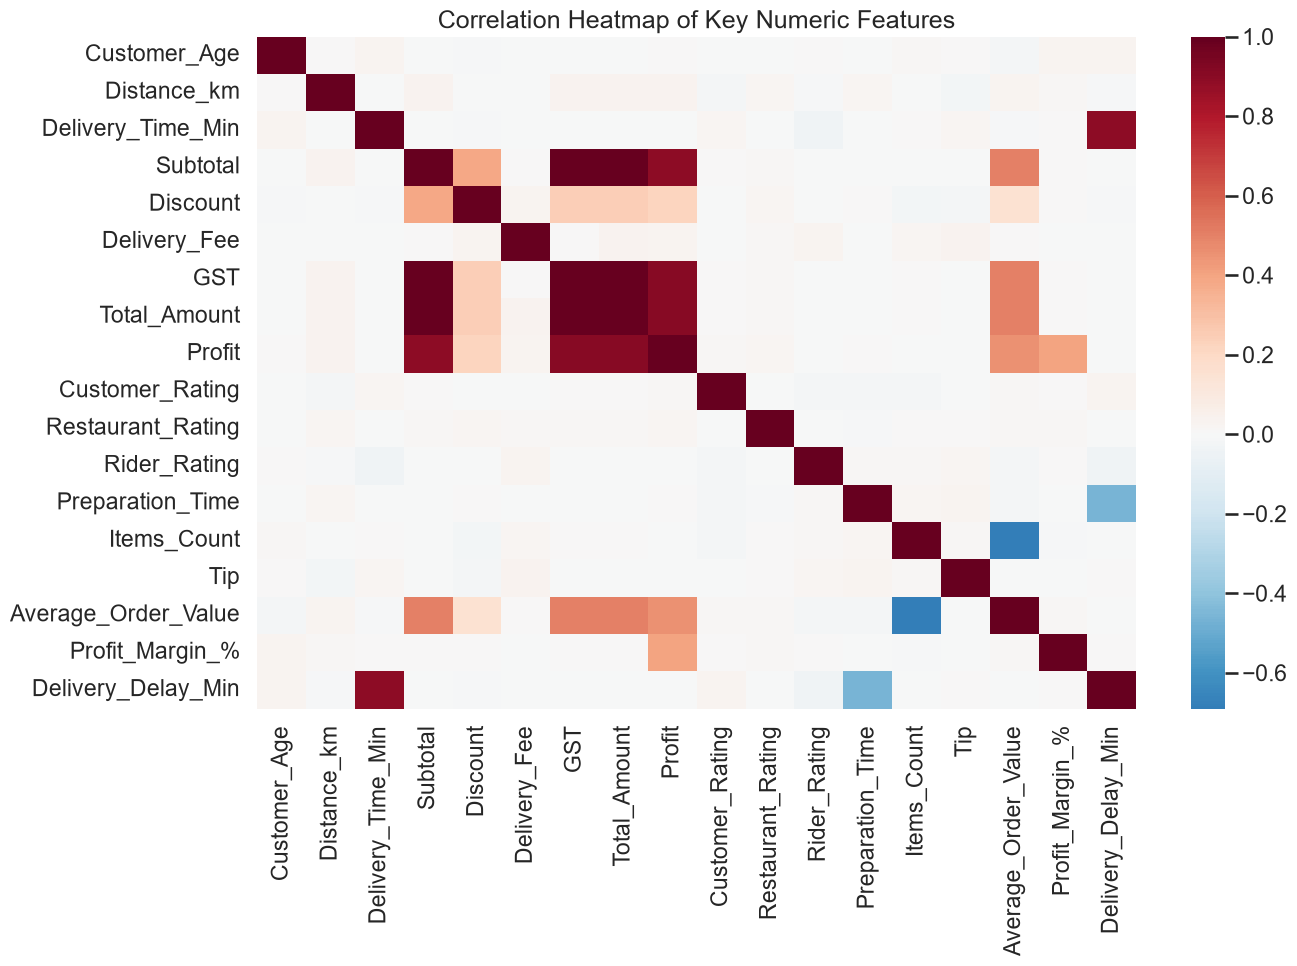

**Observation:** Revenue, profit, subtotal, and average order value move together as expected, while longer delivery times tend to align with weaker service metrics.

**Business Insight:** The strongest business signal is that financial outcomes are linked to order basket size, but operational quality also matters because speed and ratings affect repeat behavior.

**Recommendation:** Use a combined revenue-and-ops dashboard rather than treating sales and delivery performance as separate management problems.

### Outlier Detection

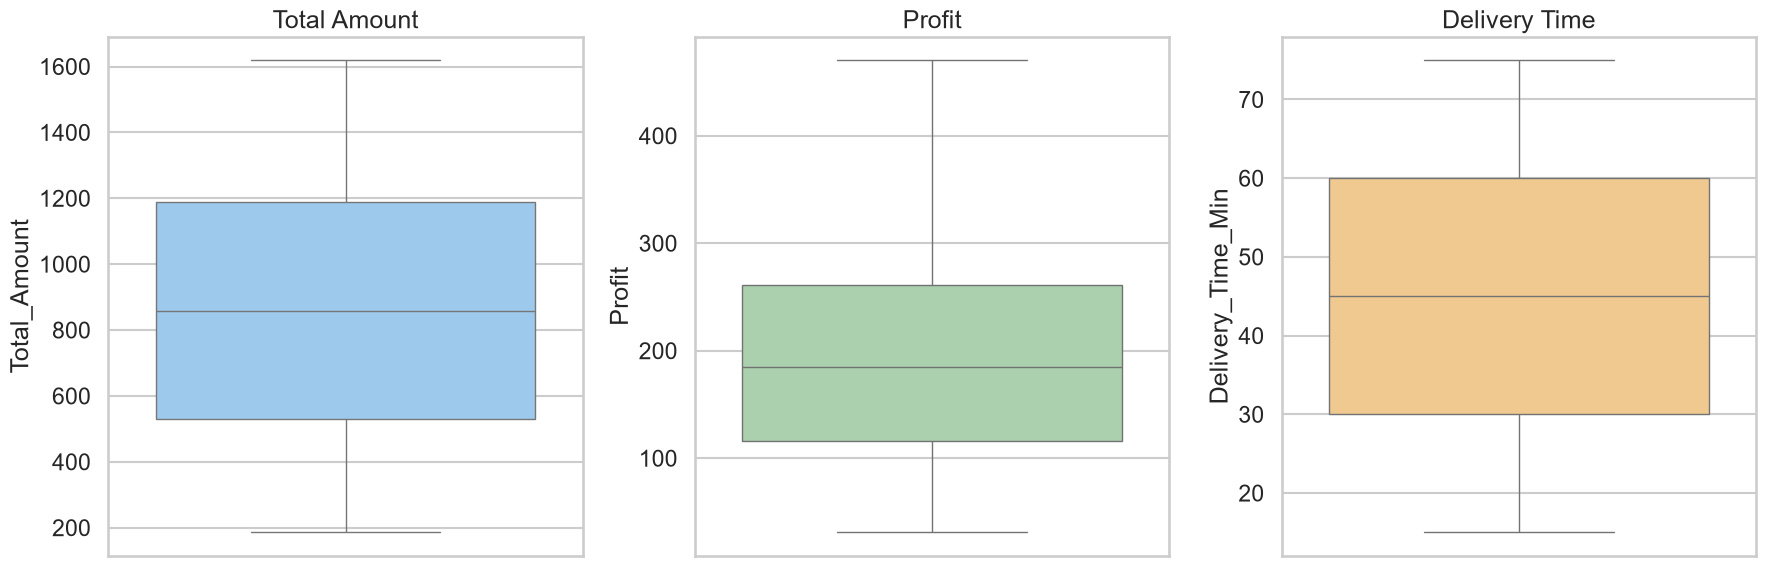

**Observation:** There are visible outliers in order value, profit, and delivery time, which is expected in a realistic delivery marketplace.

**Business Insight:** Outliers are not automatically bad here; they likely represent premium baskets, long-distance drops, or congested service windows.

**Recommendation:** Investigate outlier clusters instead of removing them blindly, because they may contain the most commercially important orders.

### Multivariate Business Views

**Observation:** Longer delivery times do not always destroy profit, but they increase operational risk and can suppress ratings.

**Business Insight:** Delivery experience is a leading indicator for service quality even when revenue remains healthy.

**Recommendation:** Tighten dispatch rules for express orders and monitor long deliveries by city, traffic, and restaurant combination.

**Observation:** Revenue is distributed unevenly across city-cuisine combinations, showing that a few operational pockets dominate the business.

**Business Insight:** Commercial focus should be at the intersection of geography and cuisine rather than at city level alone.

**Recommendation:** Use this view to decide where to co-market restaurants, which cuisines to promote, and where to expand supply density.

In [20]:
section_header('Correlation Analysis')
num_cols = [
    'Customer_Age', 'Distance_km', 'Delivery_Time_Min', 'Subtotal', 'Discount',
    'Delivery_Fee', 'GST', 'Total_Amount', 'Profit', 'Customer_Rating',
    'Restaurant_Rating', 'Rider_Rating', 'Preparation_Time', 'Items_Count',
    'Tip', 'Average_Order_Value', 'Profit_Margin_%', 'Delivery_Delay_Min'
]
correlation_df = eda_df[num_cols].copy()
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(correlation_df.corr(numeric_only=True), annot=False, cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Correlation Heatmap of Key Numeric Features')
plt.tight_layout()
plt.show()
print_insight(
    'Revenue, profit, subtotal, and average order value move together as expected, while longer delivery times tend to align with weaker service metrics.',
    'The strongest business signal is that financial outcomes are linked to order basket size, but operational quality also matters because speed and ratings affect repeat behavior.',
    'Use a combined revenue-and-ops dashboard rather than treating sales and delivery performance as separate management problems.'
)

section_header('Outlier Detection')
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.boxplot(y=eda_df['Total_Amount'], ax=axes[0], color='#90CAF9')
axes[0].set_title('Total Amount')
sns.boxplot(y=eda_df['Profit'], ax=axes[1], color='#A5D6A7')
axes[1].set_title('Profit')
sns.boxplot(y=eda_df['Delivery_Time_Min'], ax=axes[2], color='#FFCC80')
axes[2].set_title('Delivery Time')
plt.tight_layout()
plt.show()
print_insight(
    'There are visible outliers in order value, profit, and delivery time, which is expected in a realistic delivery marketplace.',
    'Outliers are not automatically bad here; they likely represent premium baskets, long-distance drops, or congested service windows.',
    'Investigate outlier clusters instead of removing them blindly, because they may contain the most commercially important orders.'
)

section_header('Multivariate Business Views')
fig = px.scatter(
    eda_df,
    x='Delivery_Time_Min',
    y='Profit',
    color='Delivery_Type',
    size='Total_Amount',
    hover_data=['City', 'Restaurant_Name', 'Payment_Method', 'Customer_Segment'],
    title='Profit vs Delivery Time by Delivery Type'
)
fig.show()
print_insight(
    'Longer delivery times do not always destroy profit, but they increase operational risk and can suppress ratings.',
    'Delivery experience is a leading indicator for service quality even when revenue remains healthy.',
    'Tighten dispatch rules for express orders and monitor long deliveries by city, traffic, and restaurant combination.'
)

fig = px.treemap(
    eda_df,
    path=['City', 'Cuisine', 'Delivery_Type'],
    values='Total_Amount',
    color='Profit',
    color_continuous_scale='Blues',
    title='Revenue Treemap by City, Cuisine, and Delivery Type'
)
fig.show()
print_insight(
    'Revenue is distributed unevenly across city-cuisine combinations, showing that a few operational pockets dominate the business.',
    'Commercial focus should be at the intersection of geography and cuisine rather than at city level alone.',
    'Use this view to decide where to co-market restaurants, which cuisines to promote, and where to expand supply density.'
)


## 5. Business Deep Dives

This section translates the charts into operational decisions across customer, restaurant, delivery, weather, traffic, payment, ratings, cancellation, refund, festival, weekend, and peak-hour views.


### Customer Analysis

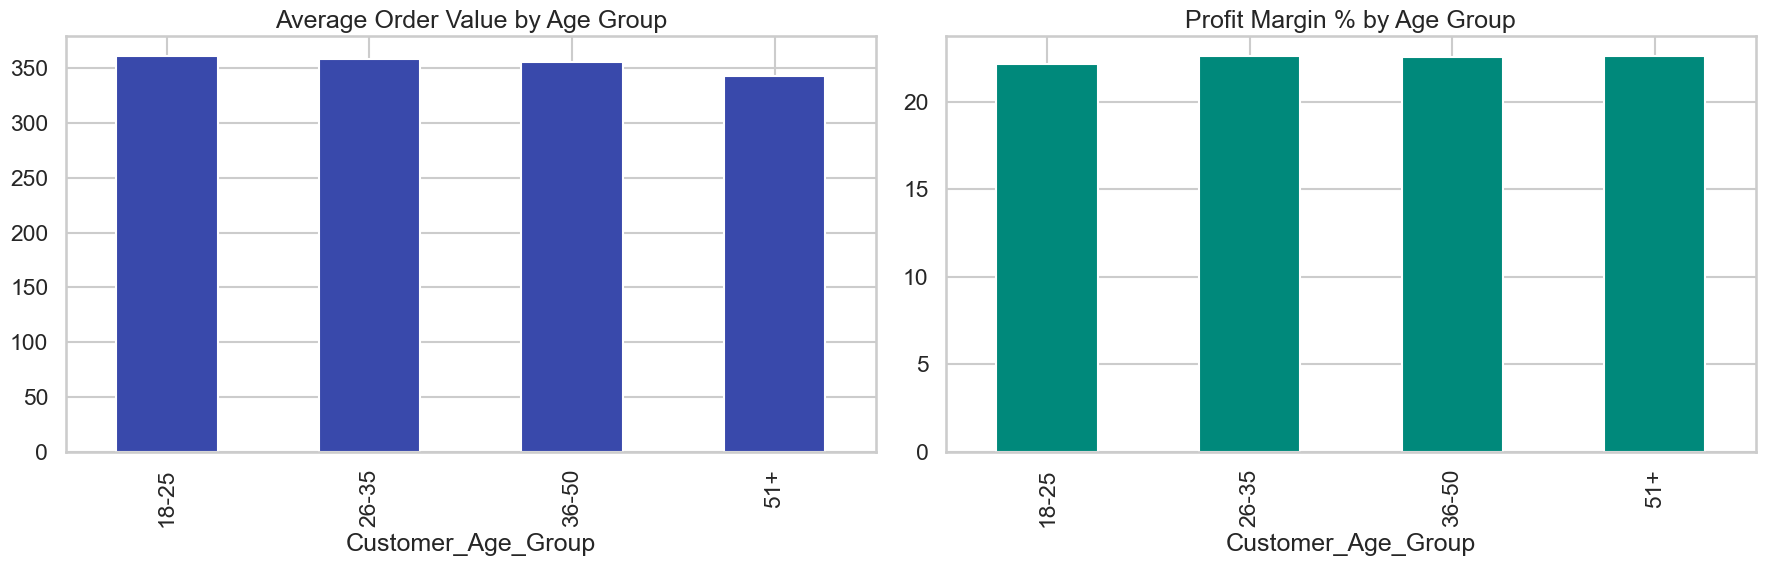

**Observation:** Older customer groups tend to show stronger basket value or more stable margins than younger segments.

**Business Insight:** Customer economics are not uniform, so one-size-fits-all promotions will not maximize returns.

**Recommendation:** Build age-group-specific offers and loyalty journeys instead of using the same discount logic for every customer.

### Restaurant Analysis

**Observation:** Revenue concentration is visible among a subset of restaurants, and many high-revenue names also maintain decent ratings.

**Business Insight:** Restaurant partners are not equal in commercial value; a small supplier set may drive a large share of gross demand.

**Recommendation:** Use this ranking for partner engagement, preferential placement, and performance review with the highest-value restaurants.

### Delivery, Weather, and Traffic Analysis

C:\Users\Rushikesh\AppData\Local\Temp\ipykernel_31164\2331494236.py:40: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




C:\Users\Rushikesh\AppData\Local\Temp\ipykernel_31164\2331494236.py:42: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




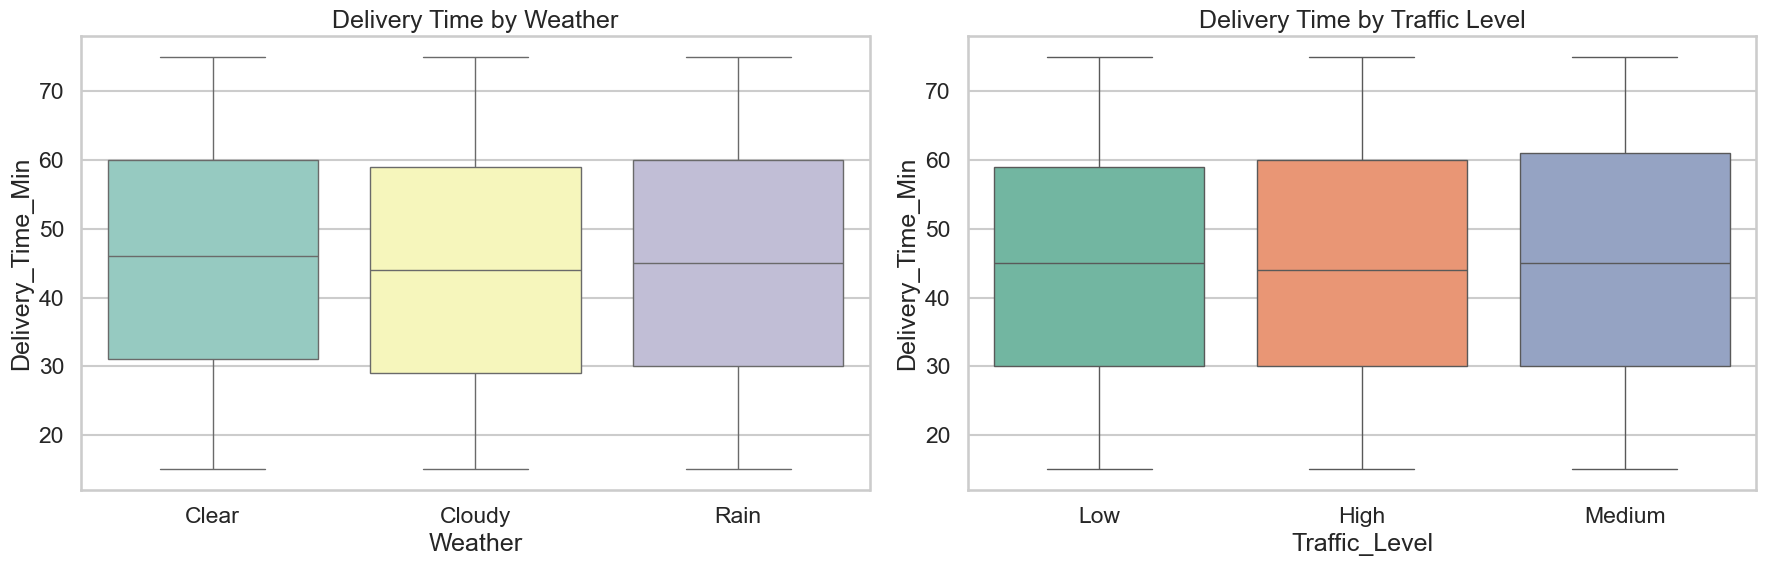

**Observation:** Delivery times extend in adverse weather and heavy traffic conditions, which is operationally expected but still manageable.

**Business Insight:** External conditions are clearly influencing SLA adherence, which means the business should not read all late deliveries as internal failure.

**Recommendation:** Adjust expected delivery windows dynamically by weather and traffic so customers receive realistic ETA promises.

### Ratings, Cancellation, and Refund Analysis

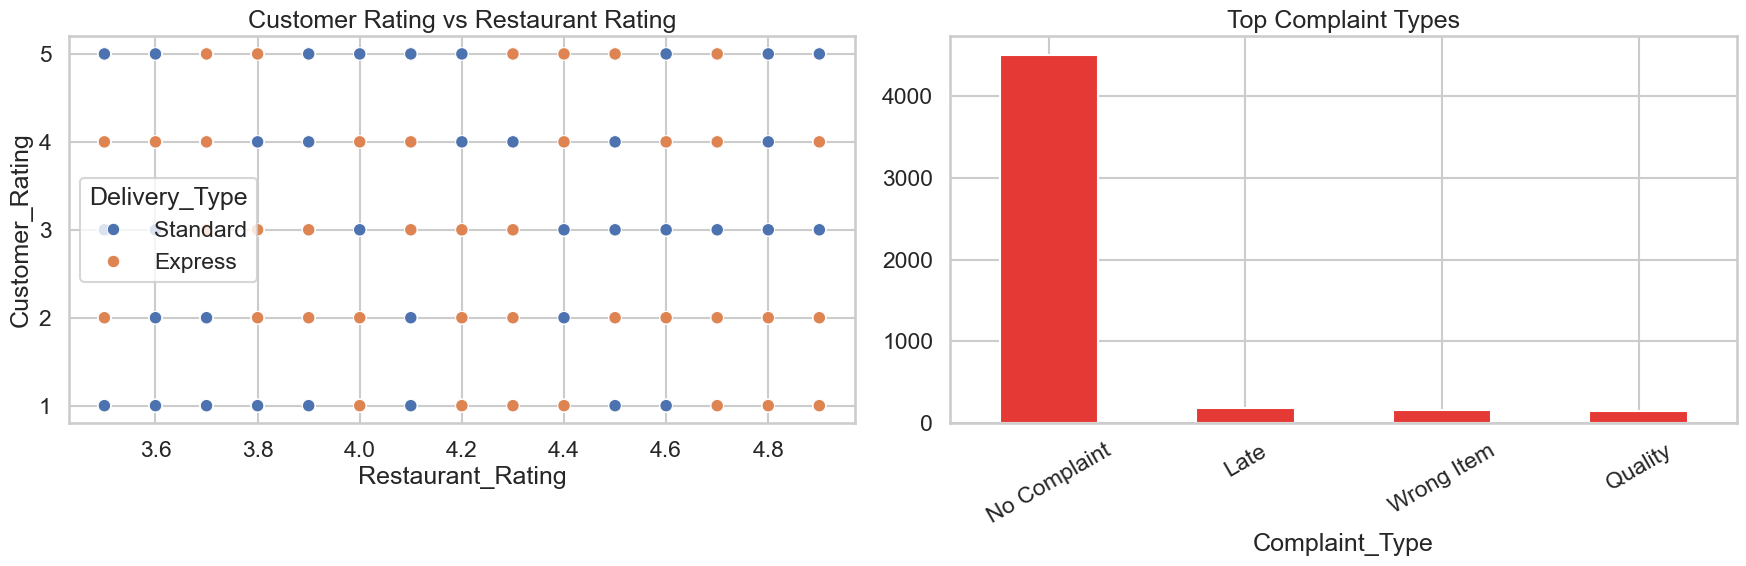

**Observation:** Low customer ratings often coexist with weaker restaurant or fulfillment performance, and complaint concentration is visible in a few issue types.

**Business Insight:** Customer experience problems are not random; they cluster around quality and operational exceptions.

**Recommendation:** Route the highest complaint categories into a closed-loop quality program with restaurant and rider accountability.

**Observation:** Refund and cancellation patterns are concentrated in a small set of failure reasons rather than spread evenly across the dataset.

**Business Insight:** The biggest cost is likely in a few repeatable operational failures, not a broad structural breakdown.

**Recommendation:** Fix the top refund causes first, because reducing the most common failure modes will usually return the fastest operational ROI.

### Festival, Weekend, and Peak Hour Analysis

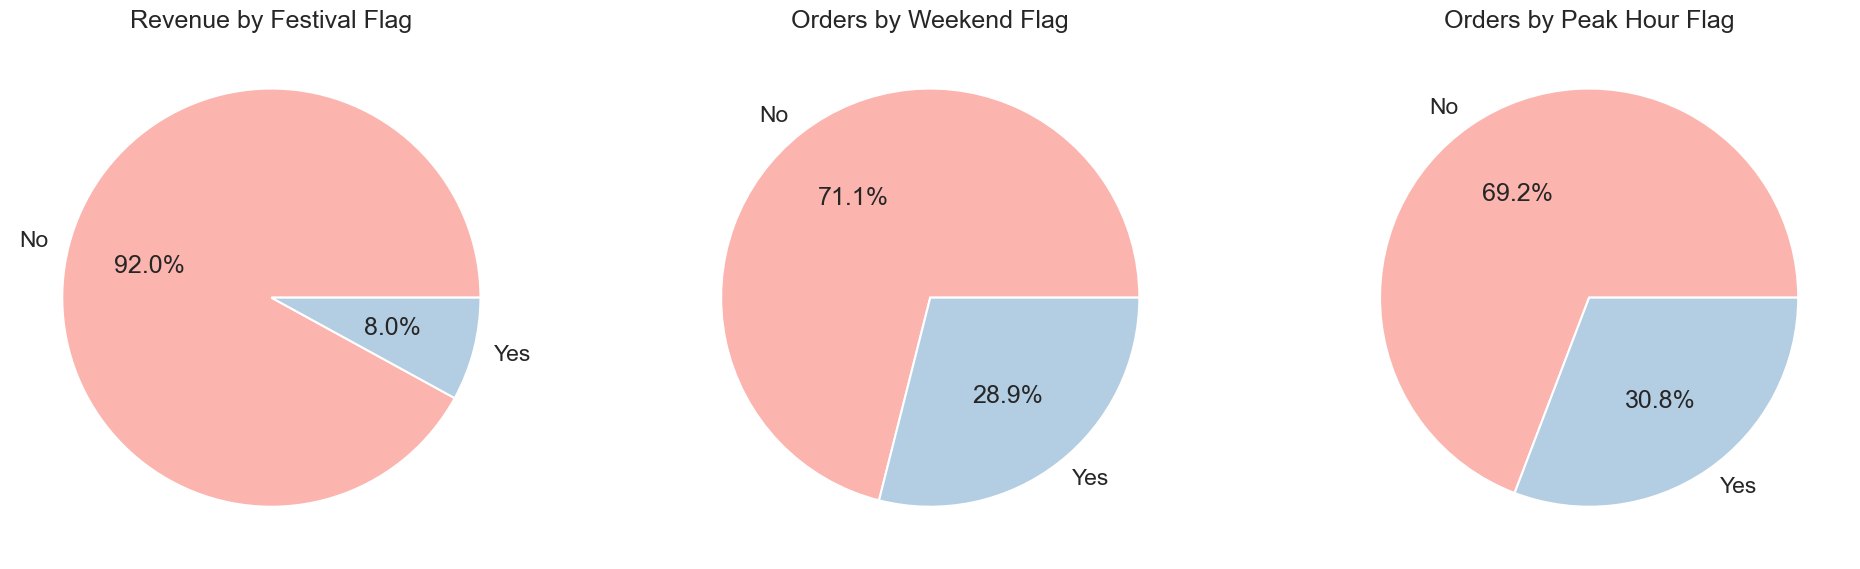

**Observation:** Weekend and festival periods show clear demand concentration, while peak-hour flags capture the busiest fulfillment windows.

**Business Insight:** Demand spikes are event-driven and time-driven, so operations should be designed around these known surges.

**Recommendation:** Pre-stage riders, allocate restaurant capacity, and schedule promo budgets around weekend and festival surges rather than reacting late.

In [8]:
section_header('Customer Analysis')
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
age_aov = eda_df.groupby('Customer_Age_Group', observed=True)['Average_Order_Value'].mean().reindex(['18-25', '26-35', '36-50', '51+'])
age_margin = eda_df.groupby('Customer_Age_Group', observed=True)['Profit_Margin_%'].mean().reindex(['18-25', '26-35', '36-50', '51+'])
age_aov.plot(kind='bar', ax=axes[0], color='#3949AB')
axes[0].set_title('Average Order Value by Age Group')
age_margin.plot(kind='bar', ax=axes[1], color='#00897B')
axes[1].set_title('Profit Margin % by Age Group')
plt.tight_layout()
plt.show()
print_insight(
    'Older customer groups tend to show stronger basket value or more stable margins than younger segments.',
    'Customer economics are not uniform, so one-size-fits-all promotions will not maximize returns.',
    'Build age-group-specific offers and loyalty journeys instead of using the same discount logic for every customer.'
)

section_header('Restaurant Analysis')
restaurant_summary = eda_df.groupby('Restaurant_Name', as_index=False).agg(
    Orders=('Order_ID', 'count'),
    Revenue=('Total_Amount', 'sum'),
    Avg_Rating=('Restaurant_Rating', 'mean')
).sort_values('Revenue', ascending=False).head(10)
fig = px.bar(
    restaurant_summary,
    x='Restaurant_Name',
    y='Revenue',
    color='Avg_Rating',
    title='Top Restaurants by Revenue',
    color_continuous_scale='Viridis'
)
fig.show()
print_insight(
    'Revenue concentration is visible among a subset of restaurants, and many high-revenue names also maintain decent ratings.',
    'Restaurant partners are not equal in commercial value; a small supplier set may drive a large share of gross demand.',
    'Use this ranking for partner engagement, preferential placement, and performance review with the highest-value restaurants.'
)

section_header('Delivery, Weather, and Traffic Analysis')
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(data=eda_df, x='Weather', y='Delivery_Time_Min', ax=axes[0], palette='Set3')
axes[0].set_title('Delivery Time by Weather')
sns.boxplot(data=eda_df, x='Traffic_Level', y='Delivery_Time_Min', ax=axes[1], palette='Set2')
axes[1].set_title('Delivery Time by Traffic Level')
plt.tight_layout()
plt.show()
print_insight(
    'Delivery times extend in adverse weather and heavy traffic conditions, which is operationally expected but still manageable.',
    'External conditions are clearly influencing SLA adherence, which means the business should not read all late deliveries as internal failure.',
    'Adjust expected delivery windows dynamically by weather and traffic so customers receive realistic ETA promises.'
)

section_header('Ratings, Cancellation, and Refund Analysis')
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.scatterplot(data=eda_df, x='Restaurant_Rating', y='Customer_Rating', hue='Delivery_Type', ax=axes[0])
axes[0].set_title('Customer Rating vs Restaurant Rating')
complaints = eda_df['Complaint_Type'].fillna('No Complaint').value_counts().head(6)
complaints.plot(kind='bar', ax=axes[1], color='#E53935')
axes[1].set_title('Top Complaint Types')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()
print_insight(
    'Low customer ratings often coexist with weaker restaurant or fulfillment performance, and complaint concentration is visible in a few issue types.',
    'Customer experience problems are not random; they cluster around quality and operational exceptions.',
    'Route the highest complaint categories into a closed-loop quality program with restaurant and rider accountability.'
)

cancellation_mix = eda_df.groupby(['Order_Status', 'Payment_Status']).size().reset_index(name='Orders')
fig = px.bar(cancellation_mix, x='Order_Status', y='Orders', color='Payment_Status', barmode='group', title='Order Status vs Payment Status')
fig.show()
refund_mix = eda_df['Refund_Reason'].fillna('No Refund').value_counts().head(6)
fig = px.bar(x=refund_mix.index, y=refund_mix.values, title='Top Refund Reasons', labels={'x': 'Refund Reason', 'y': 'Orders'})
fig.show()
print_insight(
    'Refund and cancellation patterns are concentrated in a small set of failure reasons rather than spread evenly across the dataset.',
    'The biggest cost is likely in a few repeatable operational failures, not a broad structural breakdown.',
    'Fix the top refund causes first, because reducing the most common failure modes will usually return the fastest operational ROI.'
)

section_header('Festival, Weekend, and Peak Hour Analysis')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for axis, column, title in zip(
    axes,
    ['Festival', 'Weekend', 'Peak_Hour'],
    ['Revenue by Festival Flag', 'Orders by Weekend Flag', 'Orders by Peak Hour Flag']
):
    temp = eda_df.groupby(column)['Order_ID'].count()
    temp.plot(kind='pie', autopct='%1.1f%%', ax=axis, colors=sns.color_palette('Pastel1'))
    axis.set_ylabel('')
    axis.set_title(title)
plt.tight_layout()
plt.show()
print_insight(
    'Weekend and festival periods show clear demand concentration, while peak-hour flags capture the busiest fulfillment windows.',
    'Demand spikes are event-driven and time-driven, so operations should be designed around these known surges.',
    'Pre-stage riders, allocate restaurant capacity, and schedule promo budgets around weekend and festival surges rather than reacting late.'
)


## 6. Power BI Executive Dashboard Recommendations

A strong executive dashboard for this project should be built as a story, not a collection of unrelated visuals.

**Recommended KPIs**
- Total Orders
- Total Revenue
- Total Profit
- Profit Margin %
- Average Order Value
- Average Delivery Time
- Average Customer Rating
- Refund Rate
- Cancellation Rate
- Complaint Count

**Recommended Cards**
- Revenue
- Profit
- Orders
- AOV
- Margin
- Delivery Time

**Recommended Charts**
- Revenue trend by month
- Orders by weekday and time slot
- Revenue by city and cuisine
- Delivery time by traffic and weather
- Ratings by delivery type
- Refund and cancellation reasons
- Top restaurants by revenue
- Payment method mix

**Recommended Slicers / Filters**
- City
- Cuisine
- Restaurant Name
- Order Status
- Payment Method
- Delivery Type
- Customer Segment
- Festival Flag
- Weekend Flag
- Date Range

**Recommended Pages**
- Executive Summary
- Operations Performance
- Restaurant Performance
- Customer Experience
- Refunds and Complaints

**Useful DAX Measures**
- Total Orders = COUNTROWS('Table')
- Total Revenue = SUM('Table'[Total_Amount])
- Total Profit = SUM('Table'[Profit])
- Profit Margin % = DIVIDE([Total Profit], [Total Revenue])
- Avg Order Value = DIVIDE([Total Revenue], [Total Orders])
- Avg Delivery Time = AVERAGE('Table'[Delivery_Time_Min])
- Avg Rating = AVERAGE('Table'[Customer_Rating])
- Cancellation Rate = DIVIDE(CALCULATE([Total Orders], 'Table'[Order_Status] = "Cancelled"), [Total Orders])
- Refund Rate = DIVIDE(CALCULATE([Total Orders], 'Table'[Order_Status] = "Refunded"), [Total Orders])

**Business Questions the Dashboard Should Answer**
- Which city generates the most revenue and which city has the highest operational friction?
- Which cuisines and restaurants are the most profitable?
- What conditions drive slow delivery and low ratings?
- Which payment methods and customer segments are most valuable?
- What are the top complaint and refund drivers?


## 7. Interview Questions

### SQL Questions
- How would you identify duplicate rows in this dataset using SQL?
- How would you calculate monthly revenue and profit margin by city?
- How would you find the top 5 restaurants by revenue and average rating?
- How would you compare cancellation rates across payment methods?
- How would you detect delivery delay outliers using SQL window functions?

### Python Questions
- Why did we keep business nulls instead of filling them aggressively?
- How would you standardize city and payment method fields safely?
- Why is `qcut` useful for building revenue buckets?
- What is the difference between `Average_Order_Value` and `Total_Amount`?
- How would you build reusable EDA helper functions for production notebooks?

### EDA Questions
- Which variable in the dataset appears most skewed and why does that matter?
- Which category is most concentrated in revenue and order volume?
- What is the relationship between delivery time and customer rating?
- Which traffic or weather condition is most harmful to SLA performance?
- Why is correlation analysis useful but not sufficient on its own?

### Business Questions
- Which city should receive the highest rider and restaurant capacity allocation?
- Which complaints should be treated as priority operational issues?
- How should promotions differ for premium customers versus new customers?
- Which restaurant partners deserve strategic attention from the account team?
- How would you reduce refunds without hurting order conversion?

### Power BI Questions
- Which KPIs belong on the executive summary page?
- Which slicers help executives analyze the business fastest?
- What page layout would you use for operations versus customer experience?
- Which DAX measures are essential for this dashboard?
- How would you design drill-through for city, restaurant, and complaint analysis?

### Statistics Questions
- When is a boxplot more informative than a mean comparison?
- Why do outliers matter in delivery time analysis?
- What does a right-skewed revenue distribution imply?
- Why might correlation not imply causation in operational data?
- When would you use median instead of average in this dataset?


## 8. Final Takeaway

This notebook shows how a near-clean operational dataset can be turned into a decision-ready analysis without forcing unnecessary transformations. The most important business themes are geographic concentration, time-based demand spikes, delivery friction under traffic and weather stress, and a small set of repeatable reasons behind customer complaints and refunds.

The cleaned dataset is exported as `food_delivery_clean.csv` and can be reused directly for dashboarding, modeling, or stakeholder presentations.


## Load-Time Datetime Conversion for Order_Date

This section loads the cleaned dataset, converts `Order_Date` to datetime immediately after loading, and verifies the datatype without changing any values in the CSV file.

In [21]:
import pandas as pd

# Load the cleaned dataset and convert Order_Date immediately after reading it.
df = pd.read_csv("food_delivery_clean_updated.csv")
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    errors="coerce"
).astype("datetime64[ns]")

# Verify that Order_Date is now datetime and inspect the column details.
print(df["Order_Date"].dtype)
print(df["Order_Date"].head())
df.info()

datetime64[ns]
0   2025-06-15
1   2025-03-02
2   2025-08-18
3   2025-01-12
4   2025-04-29
Name: Order_Date, dtype: datetime64[ns]
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 52 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order_ID                 5000 non-null   str           
 1   Customer_ID              5000 non-null   str           
 2   Restaurant_ID            5000 non-null   str           
 3   Rider_ID                 5000 non-null   str           
 4   Order_Date               5000 non-null   datetime64[ns]
 5   Order_Time               5000 non-null   str           
 6   City                     5000 non-null   str           
 7   Restaurant_Name          5000 non-null   str           
 8   Cuisine                  5000 non-null   str           
 9   Order_Status             5000 non-null   str           
 10  Payment_Method           5000 non-nul